### Regression :

Regression is a supervised Learning Technique which learns the pattern by understanding the relation between independent(input) and dependent(output) columns to predict the continuous values.

eg : weather Prediction, house Price Prediction , stock market Prediction.

> Regression is recommended when the output(target) column of dataset have continous values.

#### Types of Regression

1. Linear Regression
2. Polynomial Regression
3. Logistic Regression

### 01. Linear Regression

It is a supervised learning regression algorithm which learns the patterns by finding best fit line(straight) to understand relation between independent and dependent column.

#### When to use Linear Regression

If the data is linear and strongly corelated, then we can use the linear regression.

#### When not  to use Linear Regression

When data is non linear, and weakly corelated.

Y = mx + c

Y --> Predicted output

x --> New input

m --> Slope

Slope =  covariance(x,y) / variance(x)

c --> intercept

### Starting the implementation using Salary_Data

In [38]:
import pandas as pd

In [39]:
import matplotlib.pyplot as plt

In [40]:
df=pd.read_csv('Salary_Data.csv')

In [41]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [43]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


The above data has good corelation, so we can use linear regression.

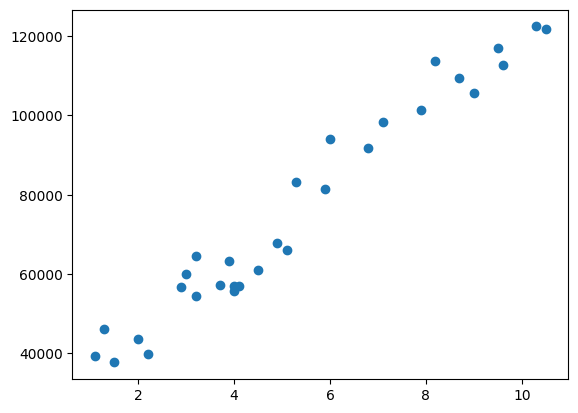

In [44]:
plt.scatter(df['YearsExperience'],df['Salary'])

In [45]:
from sklearn.linear_model import LinearRegression

step 1

Separate the independent Feature columns(as X) and dependent target column(as Y)

In [46]:
x=df[['YearsExperience']]
y=df['Salary']

step 2

Create an object to inbuilt-class LinearRegression( )

In [47]:
model=LinearRegression()

MODEL TRAINING

modelname.fit(X-train,Y-train)

Learns the patterns from input and output coloumns
Used to train the model

In [48]:
model.fit(x,y)

LinearRegression()

In [49]:
#STEP 3    Model prediction and Evaluation

model.predict([[20]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([214791.44662777])

In [50]:
slope=model.coef_
print("slope  : ",slope)
intercept=model.intercept_
print("intercept : ",intercept)

slope  :  [9449.96232146]
intercept :  25792.20019866871


# Multiple Features

Now we will implement the linear regression to the dataset which has multiple independent(input) columns

In [51]:
df1 = pd.read_csv("Student_Performance.csv")

In [52]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [53]:
df1.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [54]:
df1.corr(numeric_only=True)

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


The analysis reveals that **Previous Scores(0.915)** is the most influential factor affecting the Performance Index, followed by **Hours Studied(0.37)**. The variables **Sleep Hours(0.048)** and **Sample Question Papers Practiced(0.043)** show very weak correlations with the target variable and contribute less to predicting student performance individually.

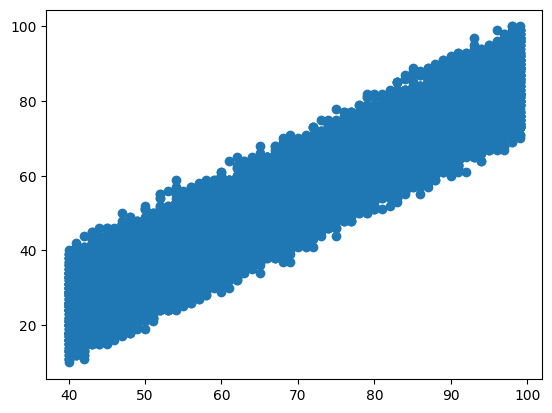

In [55]:
plt.scatter(df1['Previous Scores'],df1['Performance Index'])

In [56]:
df1['Extracurricular Activities'] = df1['Extracurricular Activities'].map({
    'Yes': 1,
    'No': 0
})

In [57]:
p = df1[['Hours Studied', 
         'Previous Scores', 
         'Extracurricular Activities', 
         'Sleep Hours', 
         'Sample Question Papers Practiced']]

q = df1['Performance Index']

# Using Train And Test split Method

In [58]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,train_size=0.8,random_slots=1.2)
                        |                       |
                        ------------|------------
                        Returns list of 4 values
                        [value1,value2,value3,value4]
                        |            | |            |
                         ------|-----   -----|------
                               X             Y
                               |_ XTrain      |_ YTrain
                               |_ XTest       |_ YTest
               

In [59]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(p,q,train_size=0.8)

In [60]:
model2 = LinearRegression()

In [61]:
model2.fit(Xtrain,Ytrain)

LinearRegression()

[[7,53,0,4,5]]

In [62]:
model2.predict([[7,53,0,4,5]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([42.75467355])

In [63]:
model2.score(Xtest,Ytest)

0.9891282542656987

In [64]:
Ypred_Train=model2.predict(Xtrain)

In [65]:
Ypre_test=model2.predict(Xtest)

#### Model Evaluation

Model evaluation starts from finding the error in each prediction.

Error = Y - Y*

Y - Actual Output

Y* - Predicted Output

### Regression Metrics :

We use various evaluation metric to evaluate the regression model, which includes :

1. MSE (Mean Square Error)         ------> Model Training And Model Evaluation

2. RMSE (Root Mean Square Error)   ------> Model Evaluation

3. MAE (Mean Absolute Error)       ------> Model Evaluation

4. R^2 Score                        ------> Model Evaluation

In [66]:
# Importing the required metrics from sklearn to evaluate the model's performance

from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error

#### MAE (Mean Absolute Error) :

We use MAE when there is a outliers in target column

In [67]:
# Evaluating the model's performance on the training set

mean_absolute_error(Ytrain,Ypred_Train)

1.6167720961485306

In [68]:
#  Evaluating the model's performance on the testing set

mean_squared_error(Ytest,Ypre_test)

4.102631633724666

#### R^2  Score:

Tells how well model captures the patterns, Retains the value of 0 and 1, sometimes -1 also.

In [69]:
r2_score(Ytrain,Ypred_Train)

0.9886528114645883

In [70]:
r2_score(Ytest,Ypre_test)

0.9891282542656987

#### MSE (Mean Square Error) :

Use MSE when no/less outliers in target column.

In [71]:
mean_absolute_error(Ytrain,Ypred_Train)

1.6167720961485306

In [72]:
mean_absolute_error(Ytest,Ypre_test)

1.6203002022111082

#### Model Evaluation Conclusion :

First    -------> R ^ 2 Score  :  which tells how well model learnt the pattern.

Next  MAE v/s RMSE ----> MAE tells the actual truth and RMSE to check the factor.

-> If MAE and RMSE are almost equal then model performance is good.

-> If RMSE is farer(more) than MAE then model failed to capture the outliers pattern

In [73]:
root_mean_squared_error(Ytrain,Ypred_Train)

2.0407178876295373

In [74]:
root_mean_squared_error(Ytest,Ypre_test)

2.0254954045182787

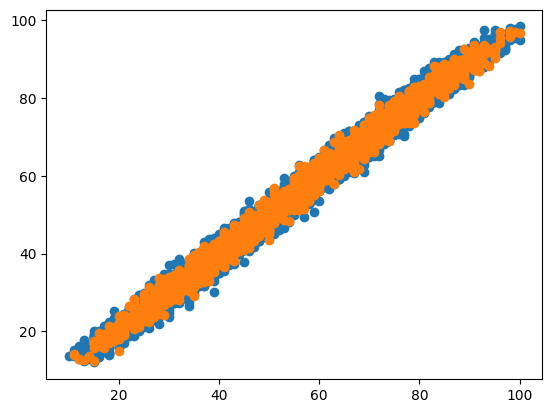

In [75]:
plt.scatter(Ytrain,Ypred_Train)
plt.scatter(Ytest,Ypre_test)